In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
ENV_NAME = 'walker' # cheetah | walker

In [3]:
NUM_TRAJECTORIES = 10000
TRAJECTORY_LEN = 1000

KEEP_ONLY_COORDS = False

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
from dm_control import suite

if ENV_NAME == 'cheetah':
    STATE_DIM = 18
    ACTION_DIM = 6
    AUX_DIM = 1
    env = suite.load(
        domain_name='cheetah',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/cheetah_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_cheetah.npy')
    dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 1)), axis=-1)
    
else:
    STATE_DIM = 27
    ACTION_DIM = 6
    AUX_DIM = 3
    env = suite.load(
        domain_name='walker',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/walker_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_walker.npy')
    dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 3)), axis=-1)

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28


In [5]:
dataset_trajectories = torch.tensor(dataset['observations']).float()
dataset_trajectories = dataset_trajectories
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions']).float()
dataset_terminals = torch.tensor(dataset['terminals']).float()
dataset_timeouts = torch.zeros(NUM_TRAJECTORIES, TRAJECTORY_LEN).bool()
dataset_timeouts[:, -1] = True

dataset_goals = torch.tensor(dataset['infos/goal']).float()



dataset_trajectories = dataset_trajectories.reshape(-1, TRAJECTORY_LEN, STATE_DIM)
dataset_actions = dataset_actions.reshape(-1, TRAJECTORY_LEN, ACTION_DIM)
dataset_terminals = dataset_terminals
dataset_timeouts = dataset_timeouts.reshape(-1, TRAJECTORY_LEN)


num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [6]:
class VelocityRewardFunctionWalker:
    def __init__(self):
        pass    

    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'gaussian':
            scale = np.sqrt(-2 * np.log(value_at_1))
            return np.exp(-0.5 * (x*scale)**2)

        elif sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='gaussian', value_at_margin=0.1):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return torch.tensor(value)
    
    def compute_reward(self, states, params):
        
        if isinstance(params, int) or isinstance(params, float):
            params = torch.full((*states.shape[:-1], 1), fill_value=params)
        
        assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

        _STAND_HEIGHT = 1.2
        horizontal_velocity = states[..., 24:25]
        torso_upright = states[..., 25:26]
        torso_height = states[..., 26:27]
        standing = self.tolerance(torso_height, lower=_STAND_HEIGHT, upper=float('inf'), margin=_STAND_HEIGHT/2)
        upright = (1 + torso_upright) / 2
        stand_reward = (3*standing + upright) / 4
        move_reward = self.tolerance(horizontal_velocity,
                                        lower=params,
                                        upper=float('inf'),
                                        margin=params/2,
                                        value_at_margin=0.5,
                                        sigmoid='linear')
        # move_reward[params == 0] = stand_reward[params == 0]
        rew = stand_reward * (5*move_reward + 1) / 6
        # rew = (5*move_reward + 1) / 6
        # rew = stand_reward
        
        return torch.tensor(rew[..., 0], dtype=torch.float32)
    
velocity_reward_function = VelocityRewardFunctionWalker()

reward_function = lambda x: velocity_reward_function.compute_reward(x, 8)

In [7]:

class LinearRewards:
    def __init__(self, N, obs_len):
        
        self.param_w1 = torch.rand(size=(N, obs_len, 1)) * 2 - 1
        self.random_mask = torch.rand(size=(N, obs_len)) < 0.9
        
        random_mask_positive = np.random.randint(2, obs_len, size=(N,))
        self.random_mask[np.arange(N), random_mask_positive] = False # Force at least one positive weight.
        
        if obs_len == 18:
            self.param_w1[:, -1:] = 0
        elif obs_len == 27:
            self.param_w1[:, -3:] = 0
        elif obs_len == 29:
            self.random_mask[..., :2] = True
    
    def __len__(self):
        return self.param_w1.shape[0]

    def sample(self, N):
        return torch.randint(0, len(self), (N,))

    def __call__(self, obs, param_id=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param_id.shape = (batch_size, 1)
        """
        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, _ = param_id.shape
        assert (batch_size == batch_size_)
        
        device = obs.device
        
        if param_id is None:
            param_id = torch.randint(0, len(self), size=(obs.shape[0], 1))
        
        param_id_expanded = param_id.repeat(1, obs.shape[1]).cpu()
        param1_w = self.param_w1[param_id_expanded].to(device)
        mask = self.random_mask[param_id_expanded].to(device)
        obs = (~mask) * obs
        
        x = torch.unsqueeze(obs, -2) # [batch, (pairs), 1, features_in]
        r = torch.matmul(x, param1_w) # [batch, (pairs), 1, features_out]
        r = r.squeeze(-1).squeeze(-1) # [batch, (pairs)]
        r = torch.clip(r, -1, 1)

        return r, param_id






class MLPRewards:
    def __init__(self, N, obs_len):
        
        self.param_w1 = torch.normal(0, 1, size=(N, obs_len, 32), device=device) * np.sqrt(1/32)
        self.param_b1 = torch.normal(0, 1, size=(N, 1, 32), device=device) * np.sqrt(16)
        self.param_w2 = torch.normal(0, 1, size=(N, 32, 1), device=device) * np.sqrt(1/16)
        
        if obs_len == 18:
            self.param_w1[:, -1:] = 0
        elif obs_len == 27:
            self.param_w1[:, -3:] = 0
        
        self.random_mask = torch.rand(size=(N, obs_len), device=device) < 0.9
        random_mask_positive = np.random.randint(2, obs_len, size=(N,))
        self.random_mask[np.arange(N), random_mask_positive] = False # Force at least one positive weight.
            
    def __len__(self):
        return self.param_w1.shape[0]
    
    def sample(self, N):
        return torch.randint(0, len(self), (N,))

    def __call__(self, obs, param_id=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param_id.shape = (batch_size, 1)
        """
        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, _ = param_id.shape
        assert (batch_size == batch_size_)
        
        device = obs.device
        
        if param_id is None:
            param_id = torch.randint(0, len(self), size=(obs.shape[0], 1))
        
        param_id_expanded = param_id.repeat(1, obs.shape[1]).cpu()
        param1_w = self.param_w1[param_id_expanded]
        param1_b = self.param_b1[param_id_expanded]
        param2_w = self.param_w2[param_id_expanded]

        # obs[..., 2:] = 0.0
        
        # mask = self.random_mask[param_id_expanded]
        # obs = (~mask) * obs
        
        
        x = torch.unsqueeze(obs, -2) # [batch, (pairs), 1, features_in]
        x = torch.matmul(x, param1_w) # [batch, (pairs), 1, features_out]
        x = x + param1_b
        x = torch.tanh(x)
        r = torch.matmul(x, param2_w) # [batch, (pairs), 1, 1]
        r = r.squeeze(-1).squeeze(-1) # [batch, (pairs)]
        r = torch.clip(r, -1, 1)

        return r, param_id


In [8]:
def pearson_corr(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:

    if x.ndim != 1 or y.ndim != 1:
        raise ValueError("Both inputs must be 1D tensors.")
    if x.size(0) != y.size(0):
        raise ValueError("Inputs must have the same length.")
    
    x_mean = x.mean()
    y_mean = y.mean()
    
    cov = ((x - x_mean) * (y - y_mean)).sum()
    stds = torch.sqrt(((x - x_mean) ** 2).sum()) * torch.sqrt(((y - y_mean) ** 2).sum())
    
    return cov / stds

In [9]:
rewards = reward_function(dataset_trajectories)

/tmp/ipykernel_20080/1880231273.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(rew[..., 0], dtype=torch.float32)


tensor([319.5035])


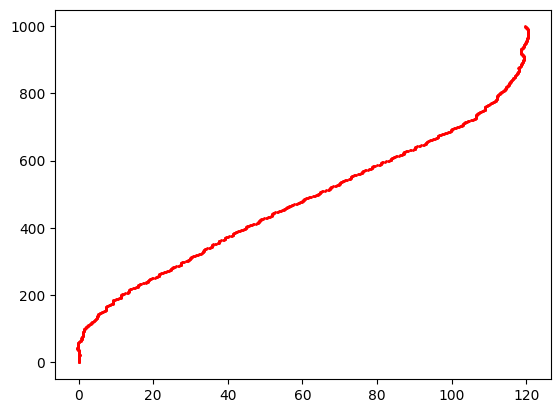

In [10]:

ids = rewards.sum(dim=1).argsort()[[-1]]

print(rewards.sum(dim=1)[ids])

plt.scatter(
    dataset['physics'][ids, :, 1],
    torch.arange(0, 1000).unsqueeze(0).repeat(ids.shape[0], 1),
    c='red', s=1
)

In [11]:
rewards[ids]

tensor([[0.1640, 0.1622, 0.1636, 0.1692, 0.1609, 0.1667, 0.1628, 0.1456, 0.1289,
         0.1019, 0.0796, 0.0909, 0.1113, 0.1263, 0.1273, 0.1341, 0.1398, 0.1433,
         0.1453, 0.1536, 0.1676, 0.1768, 0.1755, 0.1795, 0.1783, 0.1742, 0.1694,
         0.1681, 0.1718, 0.1712, 0.1603, 0.1655, 0.1636, 0.1574, 0.1455, 0.1213,
         0.0840, 0.0512, 0.0283, 0.0174, 0.0129, 0.0117, 0.0215, 0.0397, 0.0370,
         0.0346, 0.0393, 0.0238, 0.0206, 0.0232, 0.0258, 0.0242, 0.0170, 0.0092,
         0.0077, 0.0117, 0.0186, 0.0297, 0.0443, 0.0640, 0.0863, 0.1017, 0.0945,
         0.0825, 0.1220, 0.1553, 0.1397, 0.1636, 0.2045, 0.2385, 0.2648, 0.2647,
         0.2408, 0.2107, 0.1958, 0.1725, 0.1453, 0.1182, 0.0877, 0.0591, 0.0338,
         0.0130, 0.0090, 0.0094, 0.0054, 0.0053, 0.0058, 0.0083, 0.0129, 0.0128,
         0.0181, 0.0254, 0.0301, 0.0313, 0.0309, 0.0272, 0.0284, 0.0359, 0.0484,
         0.0629, 0.0818, 0.1029, 0.1627, 0.1887, 0.2094, 0.2286, 0.2430, 0.2745,
         0.3197, 0.3459, 0.3

In [12]:
env.reset()


for i in range(1000):
    
    with env.physics.reset_context():
        env.physics.set_state(dataset['physics'][ids, i])
    
    
    clear_output(True)

    img = env.physics.render(camera_id=0)
    plt.imshow(img)
    
    if rewards[ids, i] > 0.5:
        plt.scatter(1, 1, c='green', s=1000)
    else:
        plt.scatter(1, 1, c='red', s=1000)
    
    plt.show()
        
    
    
    # break

KeyboardInterrupt: 

tensor(0.3195)


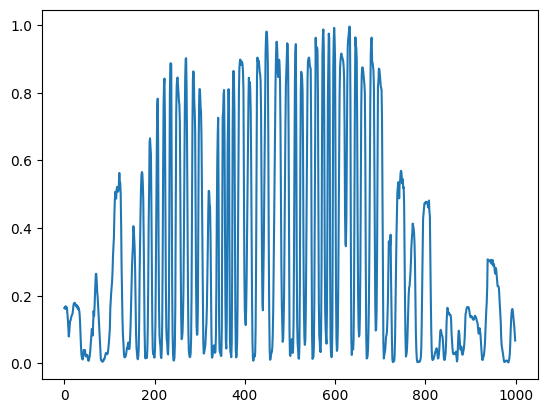

In [13]:
print(rewards[ids][0].mean())
plt.plot(rewards[ids][0])

---

In [35]:
class MLP(nn.Module):
    def __init__(self, ):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(24, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            # nn.Tanh()
        )
        
    def forward(self, x):
        return self.model(x)

In [36]:
model = MLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

losses = []

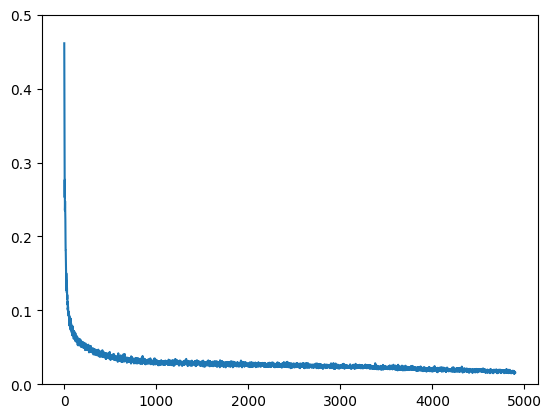

100%|██████████| 5000/5000 [00:09<00:00, 532.52it/s]


In [37]:
for i in tqdm(range(5000)):
    
    t = torch.randint(0, 10000, (512,))
    s = torch.randint(0, 1000, (512,))
    
    x = dataset_trajectories[t, s, :24].to(device)
    y = rewards[t, s].to(device)
    
    out = model(x).reshape(-1)
    
    loss = (out - y).abs().mean()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if i % 100 == 0:
        clear_output(True)
        plt.ylim([0, 0.5])
        plt.plot(losses)
        plt.show()

In [38]:
pred_rewards = torch.zeros((10000, 1000))
with torch.no_grad():
    for i in tqdm(range(10)):
        pred_rewards[1000*i:1000*(i+1)] = model(dataset_trajectories[1000*i:1000*(i+1), :, :24].flatten(0, 1).to(device)).cpu().reshape(1000, 1000)

100%|██████████| 10/10 [00:00<00:00, 25.21it/s]


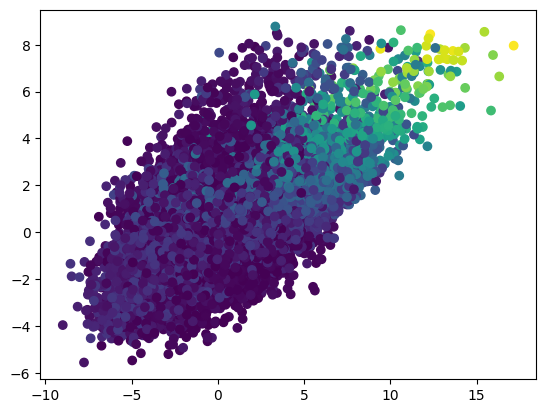

In [39]:
plt.scatter(
    dataset_trajectories[::10, ::10, 16],
    dataset_trajectories[::10, ::10, 24],
    c=rewards[::10, ::10],
    vmin=0, vmax=1
)

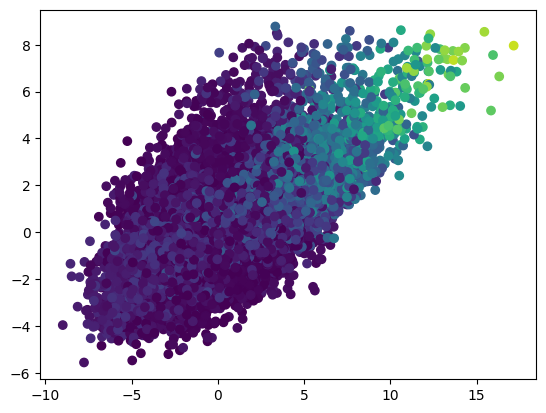

In [40]:
plt.scatter(
    dataset_trajectories[::10, ::10, 16],
    dataset_trajectories[::10, ::10, 24],
    c=pred_rewards[::10, ::10],
    vmin=0, vmax=1
)

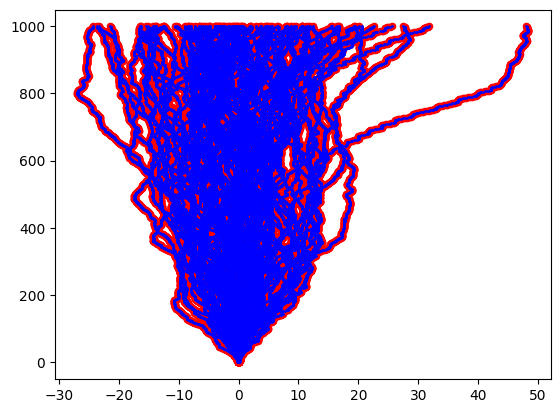

In [ ]:

ids_a = pred_rewards.sum(dim=1).argsort()[-100:]

# print(rewards.sum(dim=1)[ids])

_ = plt.scatter(
    dataset['physics'][ids_a, :, 1],
    torch.arange(0, 1000).unsqueeze(0).repeat(ids_a.shape[0], 1),
    c='red', s=20
)


ids_b = rewards.sum(dim=1).argsort()[-100:]

_ = plt.scatter(
    dataset['physics'][ids_b, :, 1],
    torch.arange(0, 1000).unsqueeze(0).repeat(ids_b.shape[0], 1),
    c='blue', s=1
)

In [ ]:
len(set(ids_a.tolist()).intersection(set(ids_b.tolist()))) / len(ids_a)

0.99

---

In [ ]:
for i in range(27):
    corr = pearson_corr(dataset_trajectories[:, :, i].reshape(-1), rewards.reshape(-1))
    # corr = pearson_corr(torch.tensor(dataset['physics'][:, :, i]).reshape(-1), rewards.reshape(-1))
    
    print(i, corr)

0 tensor(0.6079)
1 tensor(0.1499)
2 tensor(0.4284)
3 tensor(-0.1860)
4 tensor(0.2215)
5 tensor(0.1760)
6 tensor(0.1469)
7 tensor(0.1096)
8 tensor(0.4344)
9 tensor(-0.1915)
10 tensor(0.2198)
11 tensor(0.1858)
12 tensor(0.1359)
13 tensor(0.1227)
14 tensor(0.7757)
15 tensor(0.1425)
16 tensor(0.3713)
17 tensor(0.1112)
18 tensor(-0.0142)
19 tensor(0.0150)
20 tensor(-0.0037)
21 tensor(-0.0126)
22 tensor(0.0114)
23 tensor(-0.0048)
24 tensor(0.3641)
25 tensor(0.6053)
26 tensor(0.7876)


---

In [ ]:
x = dataset_trajectories[::10, ::10, :].to(device)
rewards = reward_function(dataset_trajectories[::10, ::10])

x = x.reshape(1, -1, 27)

/tmp/ipykernel_30257/1880231273.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(rew[..., 0], dtype=torch.float32)


In [ ]:
# mlp_rewards = MLPRewards(10000, 27)
mlp_rewards = LinearRewards(10000, 27)

corrs = []

for i in tqdm(range(len(mlp_rewards))):

    param_id = torch.tensor([[i]])
    
    mlp_r, _ = mlp_rewards(
        x,
        param_id
    )
    
    corr = pearson_corr(rewards.reshape(-1).cpu(), mlp_r.reshape(-1).cpu())
    corrs.append(corr.item())
    
    # break

100%|██████████| 10000/10000 [00:44<00:00, 226.29it/s]


(-1.0, 1.0)

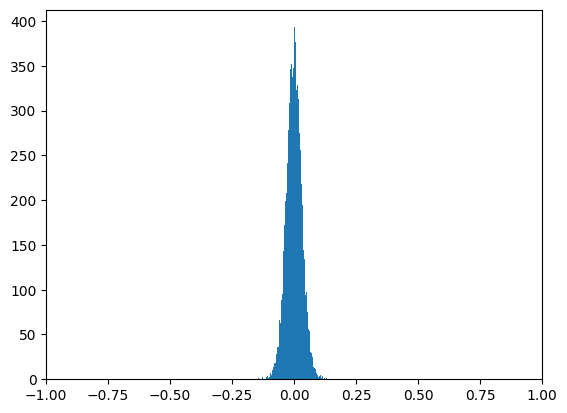

In [ ]:
_ = plt.hist(corrs, bins=100)
plt.xlim([-1, 1])

(-1.0, 1.0)

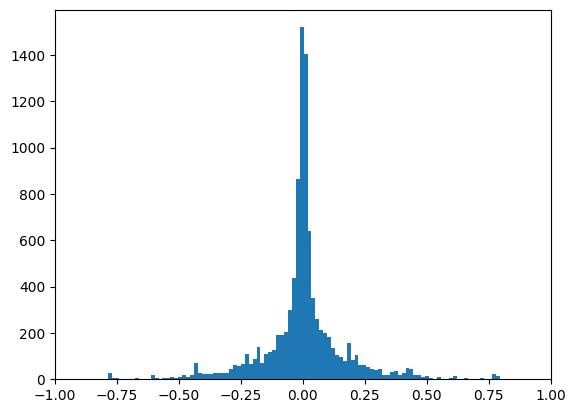

In [ ]:
_ = plt.hist(corrs, bins=100)
plt.xlim([-1, 1])

(-1.0, 1.0)

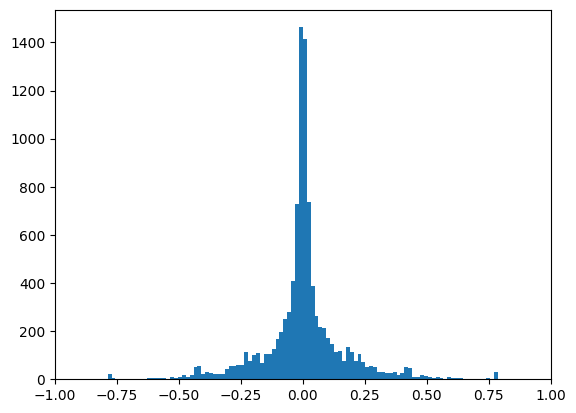

In [ ]:
_ = plt.hist(corrs, bins=100)
plt.xlim([-1, 1])

---

rewa

In [ ]:
import numpy as np

In [ ]:
x1 = np.array([
    [35, 4],
    [-1280, 292],	
    [775, 25],
    [701, 32]
])


x2 = np.array([
    [36, 8],
    [-1150, 134],
    [715, 4],
    [1215, 25]
])

mean1, std1 = x1[:, 0], x1[:, 1]
mean2, std2 = x2[:, 0], x2[:, 1]

In [ ]:
min_ = np.minimum(mean1 - std1, mean2 - std2)
max_ = np.maximum(mean1 + std1, mean2 + std2)

In [ ]:
min_, max_

(array([   28, -1572,   711,   669]), array([  44, -988,  800, 1240]))

In [ ]:
i = 0
v = 4.8

v * (max_[i] - min_[i]) / 100 + 28

28.768

In [ ]:
(39 + 185) / (215 + 185)

0.56

In [ ]:
import sympy as sp

def solve_AB(x1, y1, x2, y2):
    # Define symbols
    A, B = sp.symbols('A B', real=True)

    # Equations
    eq1 = sp.Eq((x1 - A) / (B - A), y1 / 100)
    eq2 = sp.Eq((x2 - A) / (B - A), y2 / 100)

    # Solve system
    solution = sp.solve((eq1, eq2), (A, B))
    return solution

# Example with your values:
x1, y1 = 701, 67.2
x2, y2 = 701 + 32, 67.2 + 36

sol = solve_AB(x1, y1, x2, y2)
print(sol)

{A: 641.266666666667, B: 730.155555555556}


In [ ]:
(    2 + 21 + 18 + 8 + 6    ) / 5

11.0